# Phase 5: Retail Shelf Crop Extraction 🛒
This notebook extracts individual product crops from high-resolution retail shelf images using our custom YOLO11m model.

**Required Datasets:**
1. `ch13-shelf-images`: The raw images dataset.
2. `yolo11m_sku110k`: The trained weights dataset (containing `yolo11m_sku110k_v1.pt`).

In [1]:
# Install required libraries
!pip install -q ultralytics opencv-python-headless pandas tqdm matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.1 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import cv2
import uuid
import shutil
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO

# --- Paths ---
RAW_IMAGES_DIR = Path("/kaggle/input/datasets/khalednabilfathy/ch13-shelf-images-raw/kaggle_dataset_ch13_shelf_images_raw/shelf_images")
MODEL_PATH = Path("/kaggle/input/datasets/khalednabilfathy/yolo11m-sku110k/yolo11m_sku110k_v1.pt")

WORKING_DIR = Path("/kaggle/working/data/interim")
CROPS_DIR = WORKING_DIR / "crops"
MANIFEST_PATH = WORKING_DIR / "detections_manifest.csv"

# Clean start
if CROPS_DIR.exists():
    shutil.rmtree(CROPS_DIR)
CROPS_DIR.mkdir(parents=True, exist_ok=True)

# Configuration
CONFIDENCE = 0.30
NMS_IOU = 0.50
MAX_DETECTIONS = 200
PADDING_RATIO = 0.0
MIN_CROP_DIM = 10


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
def preprocess_image(img_path, min_dim=320, max_long_side=1920):
    img = cv2.imread(str(img_path))
    if img is None:
        return None, None, {"error": "Corrupt or invalid image"}
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    # Calculate scale
    scale = 1.0
    if max(h, w) > max_long_side:
        scale = max_long_side / float(max(h, w))
        
    new_w, new_h = int(w * scale), int(h * scale)
    
    # Pad to minimums if necessary
    new_w = max(new_w, min_dim)
    new_h = max(new_h, min_dim)
    
    if (new_w, new_h) != (w, h):
        processed = cv2.resize(img_rgb, (new_w, new_h), interpolation=cv2.INTER_AREA)
    else:
        processed = img_rgb.copy()
        
    metadata = {
        "original_width": w,
        "original_height": h,
        "processed_width": new_w,
        "processed_height": new_h
    }
    return processed, img_rgb, metadata

def validate_and_extract(orig_img, xmin, ymin, xmax, ymax):
    h, w = orig_img.shape[:2]
    
    xmin, ymin = max(0, xmin), max(0, ymin)
    xmax, ymax = min(w, xmax), min(h, ymax)
    
    crop_w, crop_h = xmax - xmin, ymax - ymin
    
    if crop_w < MIN_CROP_DIM or crop_h < MIN_CROP_DIM:
        return None, "invalid"
        
    crop = orig_img[ymin:ymax, xmin:xmax]
    return crop, "valid"


In [4]:
print("Loading YOLO11m Model...")
model = YOLO(MODEL_PATH)

# Collect all images
image_paths = []
for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG"]:
    image_paths.extend(list(RAW_IMAGES_DIR.rglob(ext)))

print(f"Found {len(image_paths)} images to process.")


Loading YOLO11m Model...
Found 153 images to process.


## Part 1: Visual Verification
Let's run inference on a few sample images and plot the bounding boxes directly in the notebook. This ensures the model is loading correctly and drawing tight boundaries.

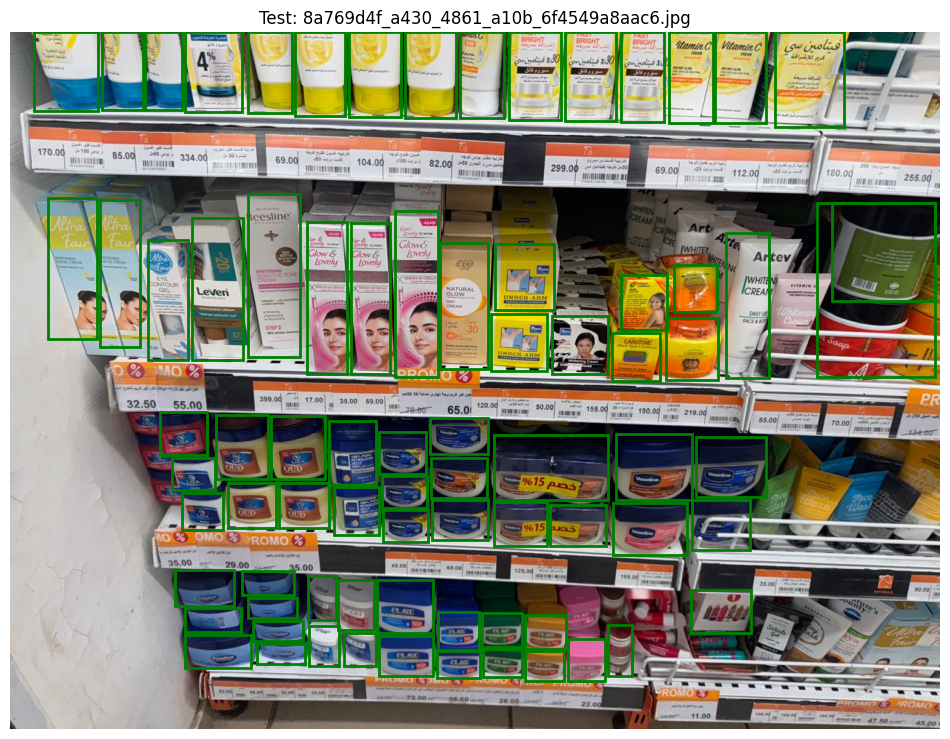

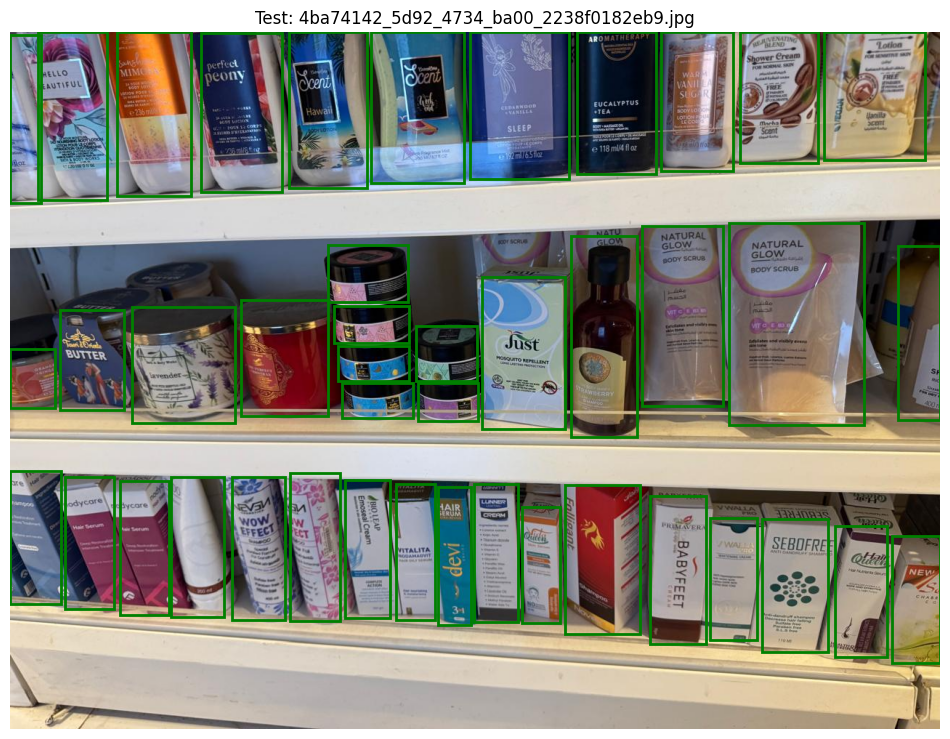

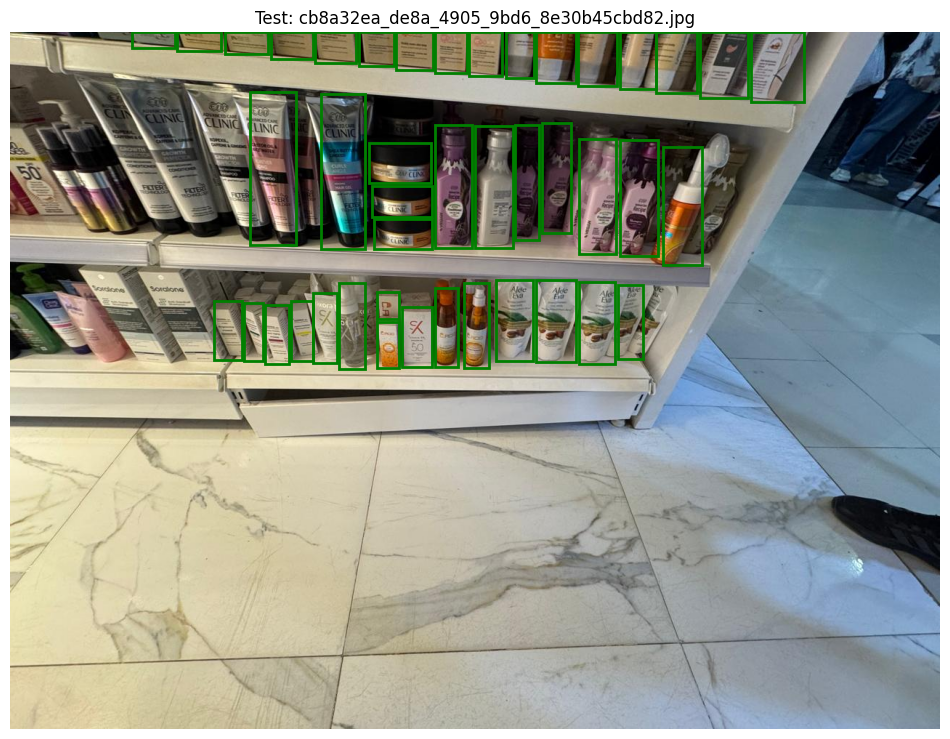

In [8]:
import matplotlib.patches as patches

sample_paths = image_paths[:3]

for img_path in sample_paths:
    processed, orig, meta = preprocess_image(img_path)
    if processed is None: continue
        
    scale_x = meta["original_width"] / meta["processed_width"]
    scale_y = meta["original_height"] / meta["processed_height"]
    
    results = model.predict(processed, conf=CONFIDENCE, iou=NMS_IOU, max_det=MAX_DETECTIONS, verbose=False)
    
    fig, ax = plt.subplots(1, figsize=(12, 12))
    ax.imshow(orig)
    ax.axis('off')
    ax.set_title(f"Test: {img_path.name}")
    
    for box in results[0].boxes:
        xyxy = box.xyxy[0].cpu().numpy()
        conf = float(box.conf[0])
        
        orig_xmin = int(xyxy[0] * scale_x)
        orig_ymin = int(xyxy[1] * scale_y)
        orig_xmax = int(xyxy[2] * scale_x)
        orig_ymax = int(xyxy[3] * scale_y)
        
        rect = patches.Rectangle(
            (orig_xmin, orig_ymin), orig_xmax - orig_xmin, orig_ymax - orig_ymin,
            linewidth=2, edgecolor='g', facecolor='none'
        )
        ax.add_patch(rect)
        
    plt.show()


## Part 2: Full Dataset Extraction
We will now loop through all images, crop the bounding boxes, save them to the crops folder, and build the manifest CSV.

In [6]:
all_detections = []
run_id = str(uuid.uuid4())[:8]

for img_path in tqdm(image_paths, desc="Extracting Crops"):
    image_id = img_path.stem
    processed, orig, meta = preprocess_image(img_path)
    if processed is None: continue
        
    scale_x = meta["original_width"] / meta["processed_width"]
    scale_y = meta["original_height"] / meta["processed_height"]
    
    results = model.predict(processed, conf=CONFIDENCE, iou=NMS_IOU, max_det=MAX_DETECTIONS, verbose=False)
    
    for box in results[0].boxes:
        xyxy = box.xyxy[0].cpu().numpy()
        conf = float(box.conf[0])
        
        orig_xmin = int(xyxy[0] * scale_x)
        orig_ymin = int(xyxy[1] * scale_y)
        orig_xmax = int(xyxy[2] * scale_x)
        orig_ymax = int(xyxy[3] * scale_y)
        
        crop_arr, status = validate_and_extract(orig, orig_xmin, orig_ymin, orig_xmax, orig_ymax)
        
        if status == "valid":
            det_id = str(uuid.uuid4())
            crop_filename = f"{image_id}_{det_id}.jpg"
            crop_out_path = CROPS_DIR / crop_filename
            
            # Save crop (convert back to BGR for cv2)
            cv2.imwrite(str(crop_out_path), cv2.cvtColor(crop_arr, cv2.COLOR_RGB2BGR))
            
            all_detections.append({
                "run_id": run_id,
                "image_id": image_id,
                "detection_id": det_id,
                "x_min": orig_xmin,
                "y_min": orig_ymin,
                "x_max": orig_xmax,
                "y_max": orig_ymax,
                "bbox_area": (orig_xmax - orig_xmin) * (orig_ymax - orig_ymin),
                "detector_confidence": conf,
                "crop_path": str(crop_out_path),
                "quality_status": "good",
                "candidate_status": "valid"
            })

df = pd.DataFrame(all_detections)
df.to_csv(MANIFEST_PATH, index=False)
print(f"\nExtraction Complete! Generated {len(df)} crops.")
print(f"Manifest saved to: {MANIFEST_PATH}")


Extracting Crops: 100%|██████████| 153/153 [00:12<00:00, 12.48it/s]



Extraction Complete! Generated 15710 crops.
Manifest saved to: /kaggle/working/data/interim/detections_manifest.csv


## Part 3: Package Results
Zip the crops and the CSV together so you can download a single archive.

In [7]:
# Note: We place the manifest INSIDE the zip so everything is neatly packaged together.
shutil.copy(MANIFEST_PATH, CROPS_DIR / "detections_manifest.csv")

print("Zipping outputs... this may take a minute...")
shutil.make_archive('/kaggle/working/phase5_outputs', 'zip', CROPS_DIR)

print("Done! You can now download phase5_outputs.zip from the Kaggle Output pane.")


Zipping outputs... this may take a minute...
Done! You can now download phase5_outputs.zip from the Kaggle Output pane.
